# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## $$ \textbf{Lista 2 - 09 de setembro de 2024}$$


In [5]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

### Questão 1: 
Para cada um dos sinais periódicos mostrados na Fig. P6.6-1, determine a série trigonométrica compacta de Fourier e trace o espectro de amplitude e fase. Se os termos em seno ou cosseno estiverem ausentes da série de Fourier, explique.

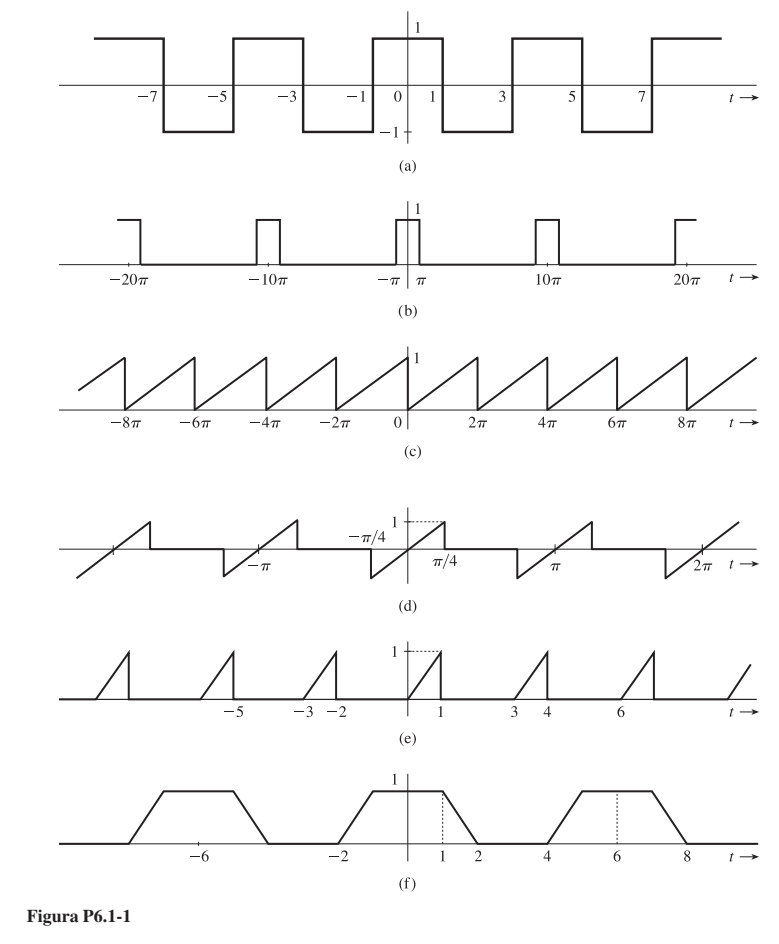

### Solução: 
Na tabela abaixo temos as representações das séries de Fouier

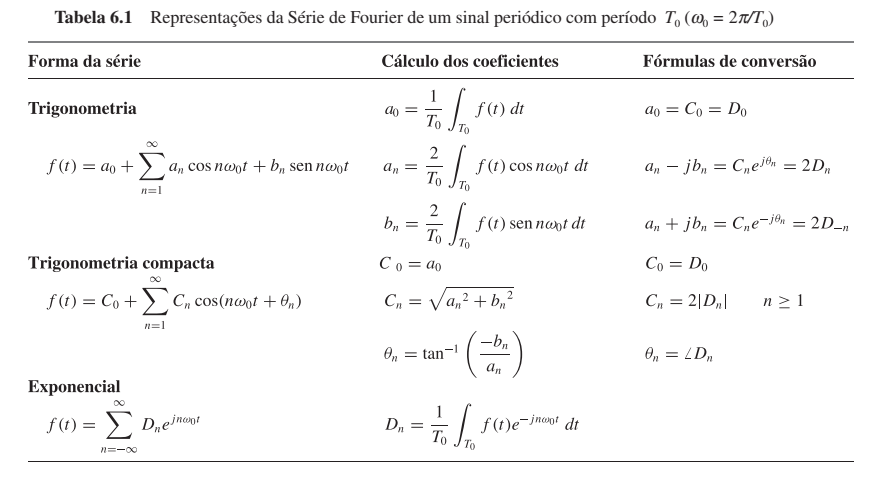

### Solução:

#### a)
Neste item vamos usar a função *fourier_series* do python. Note que $b_n \equiv 0, \forall n \in \mathbb{N}$, por conta da simetria par do sinal.

In [38]:
t = symbols('t')
g = sym.Piecewise((-1, (-2 <= t) & (t <=-1)),(1, (-1 <= t) & (t <=1)),(-1, (1 <= t) & (t <=2)), (0, True))
s = fourier_series(g, (t, -2, 2))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 5)
s3 = s.truncate(n = 20)
s4 = s.truncate(n = 50)


p1 = sym.plot(g, s1, (t, -2, 2), title='Exercício 1.a - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -2, 2), title='Exercício 1.a - $m=5$', show=False, legend=True)
p3 = sym.plot(g, s3, (t, -2, 2), title='Exercício 1.a - $m=20$', show=False, legend=True)
p4 = sym.plot(g, s4, (t, -2, 2), title='Exercício 1.a - $m=50$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p3[0].line_color = 'b'
p3[0].label = '$g(t)$'
p4[0].line_color = 'b'
p4[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=5'
p3[1].line_color = 'r'
p3[1].label = 'm=20'
p4[1].line_color = 'r'
p4[1].label = 'm=50'

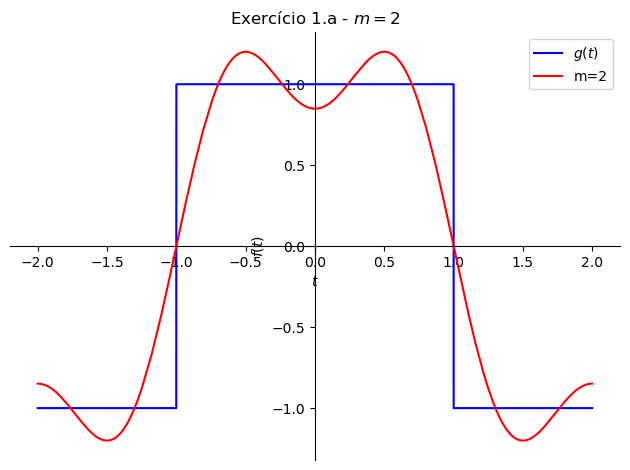

In [39]:
p1.show()

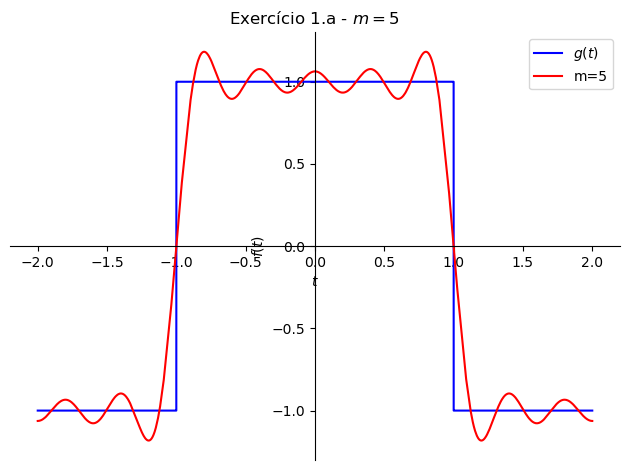

In [40]:
p2.show()

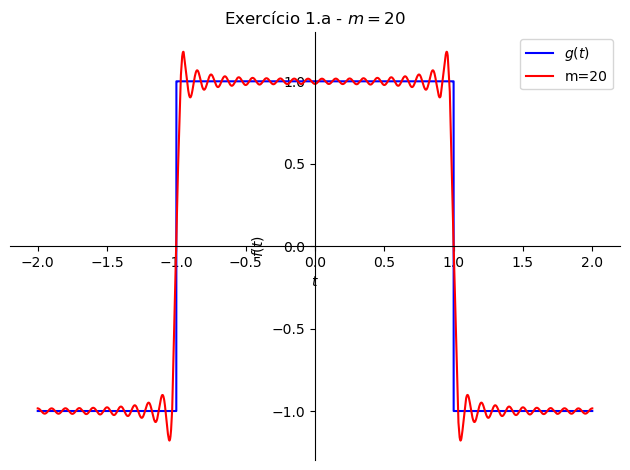

In [41]:
p3.show()

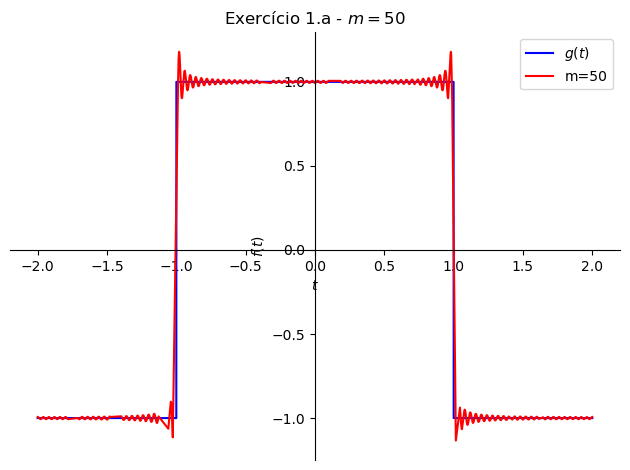

In [42]:
p4.show()

In [43]:
s

FourierSeries(Piecewise((-1, (t >= -2) & (t <= -1)), (1, (t >= -1) & (t <= 1)), (-1, (t >= 1) & (t <= 2)), (0, True)), (t, -2, 2), (0, SeqFormula(Piecewise((8*sin(_n*pi/2)/(_n*pi) - 4*sin(_n*pi)/(_n*pi), (_n > -oo) & (_n < oo) & Ne(_n, 0)), (0, True))*cos(_n*pi*t/2)/2, (_n, 1, oo)), SeqFormula(0, (_n, 1, oo))))

Por uma simples inspeção, podemos inferir que 

$$
a_0 = b_n = 0, \quad \forall n \in \mathbb{N}
$$
e que, 

$$
a_n = \frac{4}{n \pi}sin\left(\frac{n \pi}{2}\right).
$$

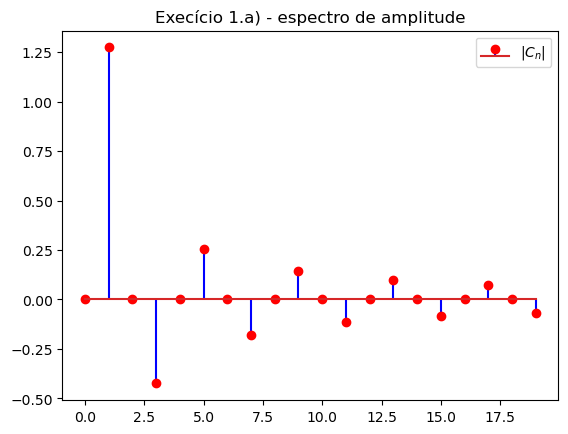

In [264]:
t = symbols('t')
z = []
C = []
th = []
for n in range(0,20):
    z.append(n)
    C.append(abs((s[n].subs(t,0))))
    #b.append(0)
    #th.append(atan2(-b[n],a[n]))
    if s[n].subs(t,0) < 0:
        th.append(-pi)
    else:
        th.append(0)
        

     
plt.stem(z, C, 'b', markerfmt='ro', label='$|C_n|$')
plt.legend()
plt.title('Execício 1.a) - espectro de amplitude')
plt.show()

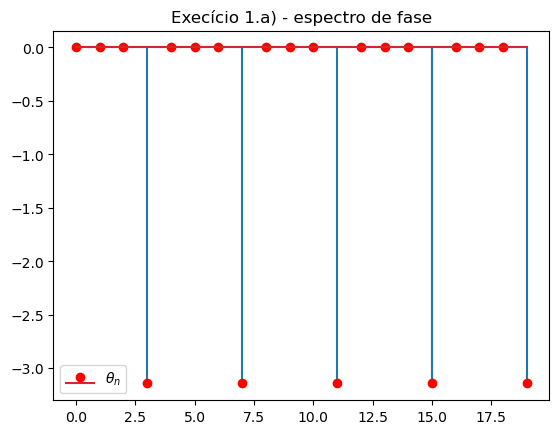

In [263]:
plt.stem(z, th, markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('Execício 1.a) - espectro de fase')
plt.show()

#### b)
Neste item, vamos fazer o exercício utilizando as definições e usando o *sympy* para calcular as integrais. Novamente, $b_n \equiv 0, \forall n \in \mathbb{N}$, por conta da simetria par do sinal.

In [265]:
T0, t = symbols('T0 t', real = True)
T0 = 10*pi
a0 = integrate(1,(t,-pi,pi))/T0
a0

1/5

In [266]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 10*pi
w0 = 2*pi/T0
an = simplify((2/T0)*integrate(1*cos(n*w0*t),(t,-pi,pi)))
an

2*sin(pi*n/5)/(pi*n)

In [153]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 10*pi
w0 = 2*pi/T0
bn = simplify((2/T0)*integrate(1*sin(n*w0*t),(t,-pi,pi)))
bn

0

In [154]:
Cn = sqrt(an**2 + bn**2)
Cn

2*Abs(sin(pi*n/5))/(pi*n)

In [155]:
phin = atan(-bn/an)
phin

0

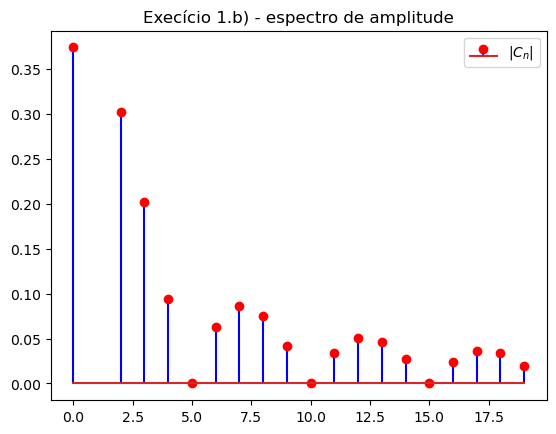

In [156]:
t = symbols('t')
z = []
C = []
th = []
for k in range(1,20):
    z.append(k)
    C.append(sqrt((an.subs(n,k))**2 + (bn.subs(n,k))**2))
    if an.subs(n,k) == 0:
        th.append(0)
    else:
        th.append(atan2(-bn.subs(n,k),an.subs(n,k)))
        
z[0] = 0
a[0] = a0
     
plt.stem(z, C, 'b', markerfmt='ro', label='$|C_n|$')
plt.legend()
plt.title('Execício 1.b) - espectro de amplitude')
plt.show()


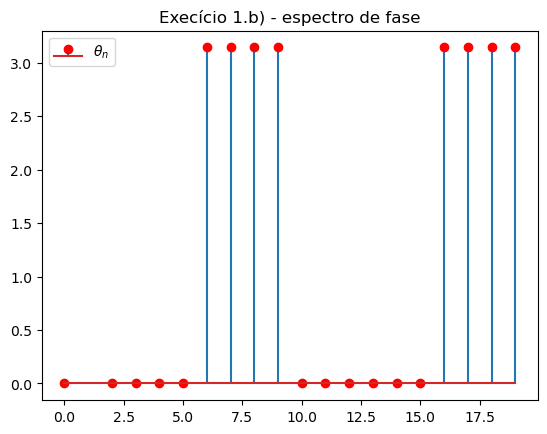

In [157]:
plt.stem(z, th, markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('Execício 1.b) - espectro de fase')
plt.show()

$$
f(t) = \frac{1}{5} + \sum_{n=1}^{\infty} \frac{2 |sin\left(\pi n / 5\right) |}{\pi n}cos\left(nt/5 \right)
$$

*c)* Neste caso, temos que

 - $T_0 = \pi$
 - $w_0 = 2$
 - $u(t) = \begin{cases} \frac{4}{\pi}t, \quad -\frac{- \pi}{4} < t < -\frac{ \pi}{4} \\
            0, \quad (-\frac{\pi}{2},-\frac{\pi}{4})  \cup (\frac{\pi}{4},\frac{\pi}{2}) \end{cases}.$

In [167]:
T0, t = symbols('T0 t', real = True)
T0 = pi
a0 = integrate(4*t/pi,(t,-pi/4,pi/4))/T0
a0

0

In [168]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = pi
w0 = 2*pi/T0
an = (2/T0)*integrate((4*t/pi)*cos(n*w0*t),(t,-pi/4,pi/4))
an

0

$a_n = 0 \quad \forall n \in \mathbb{N}$, pela simetria ímpar do sinal.

In [169]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = pi
w0 = 2*pi/T0
bn = (2/T0)*integrate((4*t/pi)*sin(n*w0*t),(t,-pi/4,pi/4))
simplify(bn)

2*(-pi*n*cos(pi*n/2) + 2*sin(pi*n/2))/(pi**2*n**2)

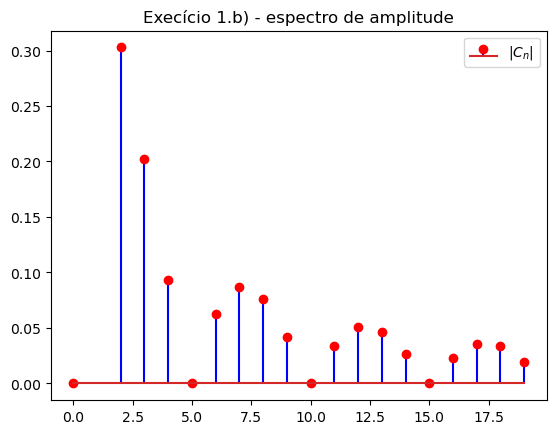

In [177]:
t = symbols('t')
z = []
C = []

th = []
for k in range(1,20):
    z.append(k)
    C.append(sqrt((an.subs(n,k))**2 + (bn.subs(n,k))**2))
    th.append(atan2(-bn.subs(n,k),an.subs(n,k)))
        
z[0] = 0
a[0] = a0
th[0] = 0
     
plt.stem(z, a, 'b', markerfmt='ro', label='$|C_n|$')
plt.legend()
plt.title('Execício 1.b) - espectro de amplitude')
plt.show()



plt.stem(z, th, markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('Execício 1.c) - espectro de fase')
plt.show()

$$
f(t) = 0 +  \sum_{n=1}^{\infty} \frac{1}{\pi n}cos\left(nt + \frac{\pi}{2} \right)
$$

### Questão 2:
Se as duas metades de um período de um sinal periódico são idênticas em forma exceto que uma é o negativo da outra, o sinal periódico é dito ter simetria de meia onda. Se um sinal periódico $x(t)$ com período $T_0$ satisfaz a condição de simetria de meia onda, então

$$
x\left(t-\frac{T_0}{2}\right)=-x(t)
$$


Neste caso, mostre que toda harmônica de número par desaparece e que os coeficientes das harmônicas de número ímpar são dados por

$$
\begin{aligned}
& a_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \cos n \omega_0 t d t \\
& b_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \operatorname{sen} n \omega_0 t d t
\end{aligned}
$$


Usando esses resultados, obtenha a série de Fourier para os sinais periódicos da Fig. P6.1-5.

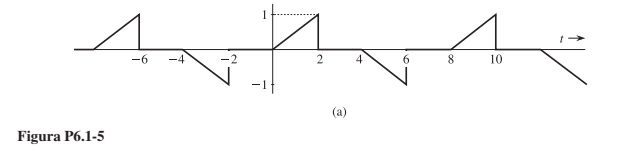

**Solução:**

Para simetria de meia onda:

$$
x(t) = -x \left( t \pm \frac{T_0}{2} \right)
$$

e

$$
a_n = \frac{2}{T_0} \int_0^{T_0} x(t) \cos n\omega_0 t \, dt = \frac{2}{T_0} \left( \int_0^{T_0/2} x(t) \cos n\omega_0 t \, dt + \int_{T_0/2}^{T_0} x(t) \cos n\omega_0 t \, dt \right).
$$

Vamos fazer $ \tau = t - T_0/2 $ na segundo integral. Isso nos dá:

$$
a_n = \frac{2}{T_0} \left( \int_0^{T_0/2} x(t) \cos n\omega_0 t \, dt + \int_0^{T_0/2} x \left( \tau + \frac{T_0}{2} \right) \cos n\omega_0 \left( \tau + \frac{T_0}{2} \right) \, d\tau \right)
$$

$$
= \frac{2}{T_0} \int_0^{T_0/2} x(t) \cos n\omega_0 t \, dt + \frac{2}{T_0} \int_0^{T_0/2} -x(\tau) [-\cos n\omega_0 \tau] \, d\tau
$$

$$
= \frac{4}{T_0} \int_0^{T_0/2} x(t) \cos n\omega_0 t \, dt.
$$

Analogamente, podemos mostrar que:

$$
b_n = \frac{4}{T_0} \int_0^{T_0/2} x(t) \sin n\omega_0 t \, dt.
$$


- $T_0 = 8$
- $w_0 = \frac{2 \pi}{T_0} = \frac{\pi}{4}$
- $
x(t) = \begin{cases}
t/2, \quad 0 < t < 2 \\
- \frac{1}{2}(t - 4), \quad 3 < t < 6
\end{cases}
$


In [267]:
t = symbols('t')
n = symbols('n', integer = True, positive = True)
T0 = 8
w0 = 2*pi/T0
a0 = integrate((t/2),(t,0,T0/4))
an = (4/T0)*integrate((t/2)*cos(n*w0*t),(t,0,T0/4))
bn = (4/T0)*integrate((t/2)*sin(n*w0*t),(t,0,T0/4))

In [268]:
a0

1.00000000000000

In [269]:
an = simplify(an)
an

(2.0*pi*n*sin(pi*n/2) + 4.0*cos(pi*n/2) - 4.0)/(pi**2*n**2)

In [271]:
bn = simplify(bn)
bn

(-2.0*pi*n*cos(pi*n/2) + 4.0*sin(pi*n/2))/(pi**2*n**2)

### Questão 3: 

Em um intervalo finito, um sinal pode ser representado por mais do que uma série de Fourier trigonométrica (ou exponencial). Por exemplo, se quisermos representar $x(t)=t$ em um intervalo $0<t<1$ por uma série de Fourier com frequência fundamental $\omega_0=2$, podemos desenhar um pulso $x(t)=t$ no intervalo $0<t<1$ e repetir o pulso a cada $\pi$ segundos, tal que $T_0=\pi$ e $\omega_0=2$ (Fig. P6.16a). 

Se quisermos que a frequência fundamental $\omega_0$ seja 4 , repetimos o pulso a cada $\pi / 2$ segundos. Se quisermos que a série contenham apenas termos em cosseno com $\omega_0=2$, construímos o pulso $x(t)=|t|$ em $-1<t<1$ e o repetimos a cada $\pi$ segundos (Fig. 6.1-6b). 

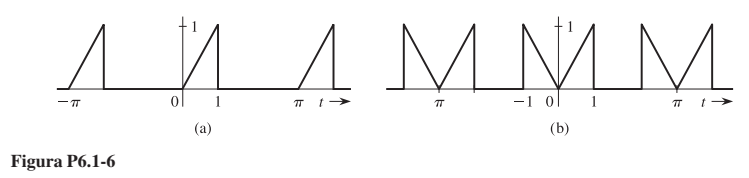

O sinal resultante será uma função par com período $\pi$. Logo, sua série de Fourier terá apenas termos em cosseno com $\omega_0=2$. A série de Fourier resultante representa $x(t)=t$ em $0 <t<1$, como desejado. Não precisamos nos preocupar com o que ela representa fora desse intervalo.

Trace um sinal periódico $x(t)$ tal que $x(t)=t$ para $0<t<1$ e que a série de Fourier para $x(t)$ satisfaça as seguintes condições.

(a) $\omega_0=\pi / 2$ e contenha todas as harmônicas, mas apenas termos em cosseno.

(b) $\omega_0=2$ e contenha todas as harmônicas, mas apenas termos em seno.

(c) $\omega_0=\pi / 2$ e contenha todas as harmônicas que não sejam exclusivamente senos ou cossenos.

(d) $\omega_0=1$ e contenha apenas harmônicas ímpares e termos em cosseno.

(e) $\omega_0=\pi / 2$ e contenha apenas harmônicas ímpares, mas apenas termos em seno.

(f) $\omega_0=1$ e contenha apenas harmônicas ímpares que não sejam exclusivamente senos ou cossenos.

[Dica: para as partes (d), (e) e (f), você precisará utilizar a simetria de meia onda discutida no Prob. 6.1-5. Termos em cosseno implicam possível componente cc.]
Você deve apenas traçar o sinal periódico $x(t)$ que satisfaça as condições dadas. Não determine os valores dos coeficientes de Fourier.

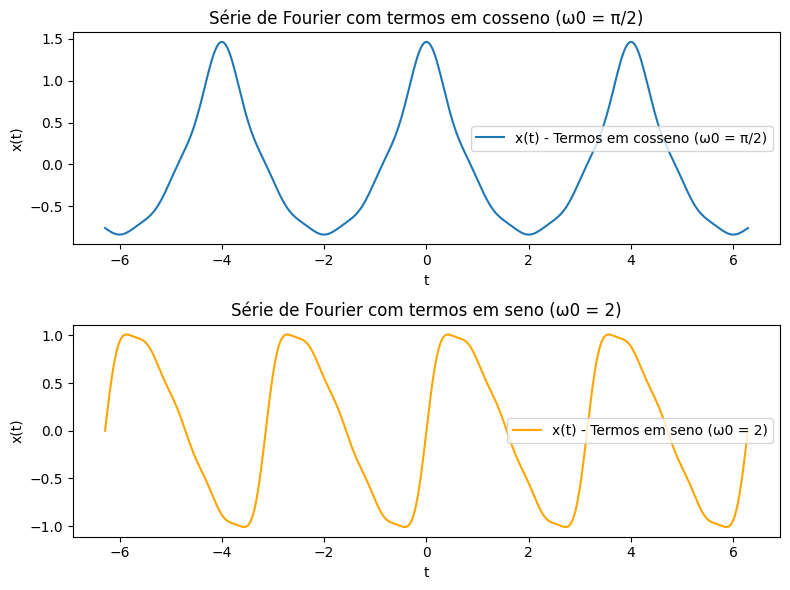

In [8]:
# Definir variável tempo e frequência fundamental ω0
t = sym.symbols('t', real=True)
n = sym.symbols('n', integer=True)

# Definindo a função base x(t) = t para 0 < t < 1
x_t = t  # sinal básico

# Condição para ω0 = π/2 e termos em cosseno (a)
ω0_a = sym.pi / 2
x_cos_a = sym.summation(sym.cos(n * ω0_a * t) / n**2, (n, 1, 5))

# Condição para ω0 = 2 e termos em seno (b)
ω0_b = 2
x_sin_b = sym.summation(sym.sin(n * ω0_b * t) / n**2, (n, 1, 5))

# Gerar gráficos dessas funções

# Função para converter sympy para numpy
def sympy_to_numpy(expr, t_vals):
    func = sym.lambdify(t, expr, "numpy")
    return func(t_vals)

# Definir intervalo de tempo para plotar
t_vals = np.linspace(-2*np.pi, 2*np.pi, 400)

# Converter para numpy as expressões de Fourier obtidas
x_cos_a_vals = sympy_to_numpy(x_cos_a, t_vals)
x_sin_b_vals = sympy_to_numpy(x_sin_b, t_vals)

# Plotar gráficos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico para ω0 = π/2 com cossenos (a)
ax[0].plot(t_vals, x_cos_a_vals, label='x(t) - Termos em cosseno (ω0 = π/2)')
ax[0].set_title('Série de Fourier com termos em cosseno (ω0 = π/2)')
ax[0].set_xlabel('t')
ax[0].set_ylabel('x(t)')
ax[0].legend()

# Gráfico para ω0 = 2 com senos (b)
ax[1].plot(t_vals, x_sin_b_vals, label='x(t) - Termos em seno (ω0 = 2)', color='orange')
ax[1].set_title('Série de Fourier com termos em seno (ω0 = 2)')
ax[1].set_xlabel('t')
ax[1].set_ylabel('x(t)')
ax[1].legend()

plt.tight_layout()
plt.show()

### Questão 4: 

Um sinal periódico $x(t)$ é descrito pela seguinte série de Fourier:

$$
x(t)=3 \cos t+\operatorname{sen}\left(5 t-\frac{\pi}{6}\right)-2 \cos \left(8 t-\frac{\pi}{3}\right)
$$

(a) Trace o espectro de amplitude e fase para a série trigonométrica.

(b) Por inspeção do espectro da parte (a), trace o espectro da série exponencial de Fourier.

(c) Por inspeção do espectro da parte (b), escreva a série exponencial de Fourier de $x(t)$.

(d) Mostre que série determinada na parte (c) é equivalente à série trigonométrica de $x(t)$.

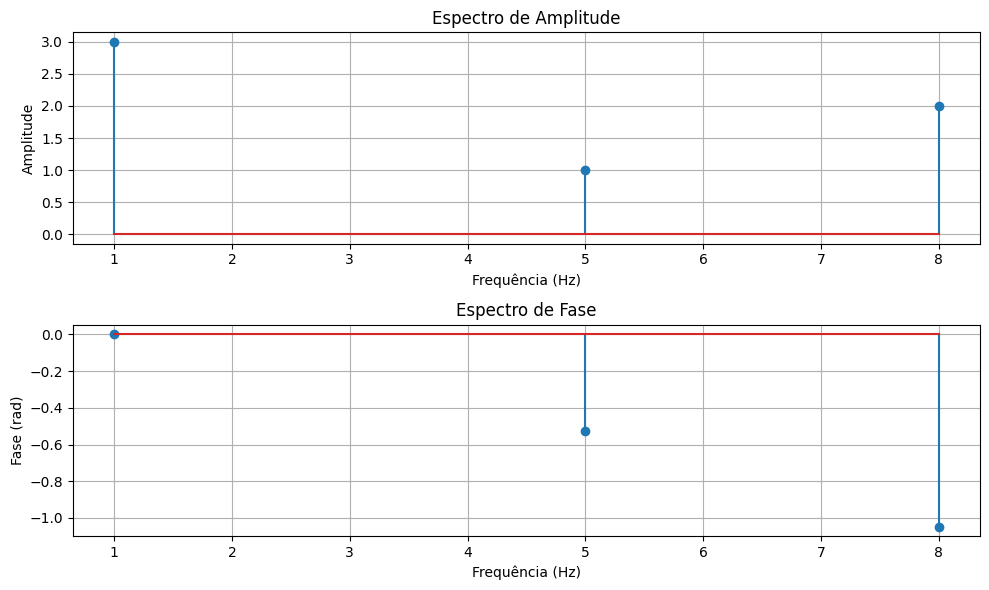

exp(-I*pi/6)*exp(0.159154943091895*I*t) + 3 + 2*exp(-I*pi/3)*exp(-0.159154943091895*I*t)

In [7]:
# Definindo a variável
t = sym.symbols('t')

# Definindo a função x(t) da série de Fourier
x_t = 3 * sym.cos(t) + sym.sin(5*t - sym.pi/6) - 2 * sym.cos(8*t - sym.pi/3)

# Coeficientes da série de Fourier
# Para a série trigonométrica, os coeficientes são extraídos
# dos termos da função dada.

# Amplitudes e fases
amplitudes = [3, 1, 2]
frequencies = [1, 5, 8]
phases = [0, -sym.pi/6, -sym.pi/3]

# (a) Spectrum amplitude and phase
frequencies_positive = np.array(frequencies)
amplitudes_positive = np.array(amplitudes)
phases_positive = np.array(phases)

# Gráfico do espectro de amplitude
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.stem(frequencies_positive, amplitudes_positive)
plt.title('Espectro de Amplitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()

# Gráfico do espectro de fase
plt.subplot(2, 1, 2)
plt.stem(frequencies_positive, phases_positive)
plt.title('Espectro de Fase')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (rad)')
plt.grid()

plt.tight_layout()
plt.show()

# (b) Spectrum da série exponencial de Fourier
# Para a série exponencial, a relação é dada por:
# a_n = Amplitude * e^(j*phase)

# Cálculo dos coeficientes da série exponencial
complex_coefficients = [amplitudes[i] * sym.exp(sym.I * phases[i]) for i in range(len(amplitudes))]

# Frequências correspondentes
frequencies_exponential = [0, 1, -1, 5, -5, 8, -8]  # considerando as frequências negativas
complex_coefficients_exponential = [0] + [complex_coefficients[i] for i in range(len(complex_coefficients))] + [complex_coefficients[i] for i in range(len(complex_coefficients))]

# (c) Série exponencial de Fourier
# Escrevendo a série exponencial
T0 = 2 * np.pi  # Período fundamental
n_terms = len(complex_coefficients)
fourier_exponential_series = sum(complex_coefficients[i] * sym.exp(sym.I * frequencies_exponential[i] * t / T0) for i in range(len(complex_coefficients)))

fourier_exponential_series

### Questão 5: 

A Fig. P6.3-6 mostra o espectro trigonométrico de Fourier de um sinal periódico $x(t)$.

(a) Por inspeção da Fig. P6.3-6, determine a série trigonométrica de Fourier que representa $x(t)$.

(b) Por inspeção da Fig. P6.3-6, trace o espectro exponencial de Fourier de $x(t)$.

(c) Por inspeção do espectro exponencial de Fourier obtido na parte (b), determine a série exponencial de Fourier de $x(t)$.

(d) Mostre que as séries determinadas nas partes (a) e (c) são equivalentes.


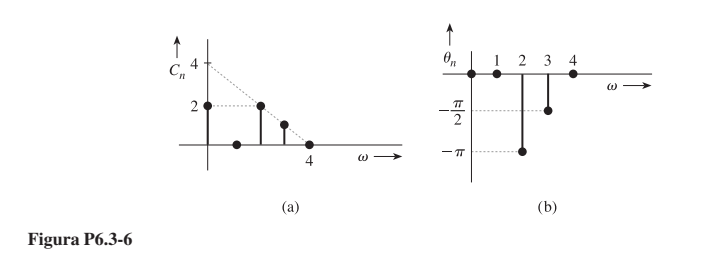

In [10]:
# Definindo as variáveis
t, w0 = sym.symbols('t w0', real=True)
n = sym.symbols('n', integer=True)

# Definir as constantes obtidas pelo gráfico da série trigonométrica de Fourier
a0 = 0  # Como não há componente DC, a0 = 0
a_n = 4 / (n**2)  # Coeficientes a_n obtidos do gráfico (decai com n^2)
b_n = sym.Piecewise((0, n % 2 == 0), (-2/n, n % 2 == 1))  # Coeficiente b_n: depende de n (somente senos ímpares)

# Série trigonométrica de Fourier
x_trig = a0 + sym.summation(a_n * sym.cos(n*w0*t) + b_n * sym.sin(n*w0*t), (n, 1, 5))

# Determinando os coeficientes da série exponencial
c_n = (a_n - sym.I * b_n) / 2
c_minus_n = (a_n + sym.I * b_n) / 2

# Série exponencial de Fourier
x_exp = sym.summation(c_n * sym.exp(sym.I * n * w0 * t) + c_minus_n * sym.exp(-sym.I * n * w0 * t), (n, 1, 5))

# Mostrar as expressões obtidas
x_trig, x_exp.simplify()

# Reajustando a definição dos coeficientes com base na análise do gráfico
# A série será recalculada com os coeficientes reais observados

# Definindo coeficientes manuais baseados no gráfico da série
C_n_vals = {1: 4, 2: 2, 3: 1}  # Coeficiente de magnitude dos primeiros 3 harmônicos
theta_n_vals = {1: -sym.pi/2, 2: -sym.pi/2, 3: -sym.pi/2}  # Fases baseadas no gráfico da série

# Reescrevendo a série trigonométrica
x_trig_redef = sum(C_n_vals[n] * sym.cos(n*w0*t + theta_n_vals[n]) for n in C_n_vals.keys())

# Definindo os coeficientes da série exponencial
c_n_vals = {n: C_n_vals[n] * sym.exp(sym.I * theta_n_vals[n]) for n in C_n_vals.keys()}

# Série exponencial de Fourier
x_exp_redef = sum(c_n_vals[n] * sym.exp(sym.I * n * w0 * t) for n in c_n_vals.keys())

# Mostrar as expressões simplificadas
x_trig_redef, x_exp_redef.simplify()

(4*sin(t*w0) + 2*sin(2*t*w0) + sin(3*t*w0),
 I*(-exp(2*I*t*w0) - 2*exp(I*t*w0) - 4)*exp(I*t*w0))

### Questão 6: 

(a) Determine a série exponencial de Fourier para o sinal $x(t)=\cos 5 t \operatorname{sen} 3 t$. Você pode obtê-la sem calcular nenhuma integral.

(b) Trace o espectro de Fourier.

<span style="color:red">**Desconsiderar** este item:     
(c) O sinal $x(t)$ é aplicado a entrada de um sistema LCIT com resposta em frequência mostrada na Fig. P6.4-2. Obtenha a saída $y(t)$.</span>

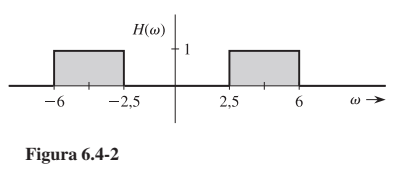

**Solução:**

(a) Usando propriedades trigonométricas, obtemos

$$
\begin{aligned}
\cos 5 t \sin 3 t & =\frac{1}{2}[\sin 8 t-\sin 2 t] \\
& =\frac{1}{4 j}\left[e^{j 8 t}-e^{-j 8 t}-e^{j 2 t}+e^{-j 2 t}\right] \\
& =\frac{1}{4}\left[e^{j \pi / 2} e^{-j 8 t}+e^{-j \pi / 2} e^{-j 2 t}+e^{j \pi / 2} e^{j 2 t}+e^{-j \pi / 2} e^{j 8 t}\right] \\
& =\frac{e^{j \pi / 2}}{4} e^{-j 4 \omega_0 t}+\frac{e^{-j \pi / 2}}{4} e^{-j \omega_0 t}+\frac{e^{j \pi / 2}}{4} e^{j \omega_0 t}+\frac{e^{-j \pi / 2}}{4} e^{j 4 \omega_0 t}
\end{aligned}
$$

Esta é a série de Fourier exponencial desejada, onde $\omega_0=2$.


(b) Existem quatro componentes espectrais diferentes de zero, localizados em $n= \pm 1$ e $\pm 4(\omega= \pm 2$ e $\pm 8)$. As fases são $\frac{\pi}{2}$ ou $-\frac{\pi}{2}$, como mostrado no espectro na figura.

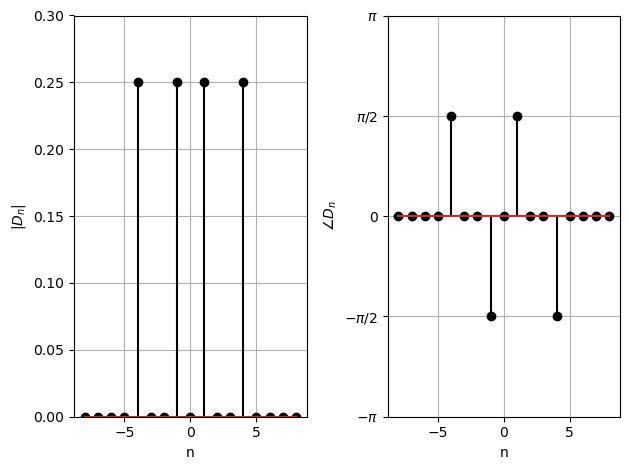

In [252]:
# intervalo de n
n = np.arange(-8, 9)

# valores dos coeficientes D_n
D_n_magnitude = [0]*17
D_n_phase = [0]*17

# preenchimento dos coeficientes
D_n_magnitude = [0,0,0,0,0.25,0,0,0.25,0,0.25,0,0,0.25,0,0,0,0]  # Coloca valores de magnitude nos pares
D_n_phase = [0,0,0,0,pi/2,0,0,-pi/2,0,pi/2,0,0,-pi/2,0,0,0,0]  # Coloca valores de fase nos ímpares

# Plotando a magnitude |Dn|
plt.subplot(121)
plt.stem(n, D_n_magnitude, 'k.')#, use_line_collection=True)
plt.xlabel('n')
plt.ylabel(r'$|D_n|$')
plt.grid(True)
plt.ylim([0, 0.3])

# Plotando a fase ∠Dn
plt.subplot(122)
plt.stem(n, D_n_phase, 'k.')#, use_line_collection=True)
plt.xlabel('n')
plt.ylabel(r'$\angle D_n$')
plt.grid(True)
plt.ylim([-np.pi, np.pi])
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

# Mostrar o gráfico
plt.tight_layout()
plt.show()


(c) Como nenhum dos componentes espectrais de $x(t)$ aparece na banda de passagem do filtro, a saída é $y(t)=0$.

### Questão 7: 
<span style="color:red">**Desconsiderar** essa questão: 

    (a) Determine a série exponencial de Fourier para um sinal periódico $x(t)$ mostra na Fig. P6.4-3a.

    (b) O sinal $x(t)$ é aplicado a entrada do sistema LCIT mostrado na Fig. P6.4-3b. Determine a expressão para a saída $y(t)$.
</span>

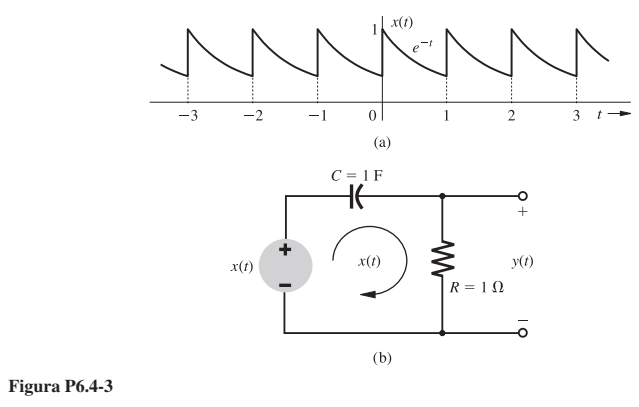

### Questão 8: 

Obtenha a transformada de Fourier de $x(t)=\operatorname{ret}(t / \tau)$. Trace o espectro de amplitude $|X(\omega)|$ e o espectro de fase $\angle X(\omega)$.

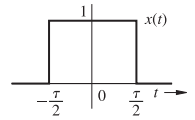

## Solução:

Como ret $(t / \tau)=1$ para $|t|<\tau / 2$ e zero para $|t|>\tau / 2$,

$$
\begin{aligned}
X(\omega) & =\int_{-\tau / 2}^{\tau / 2} e^{-j \omega t} d t \\
& =-\frac{1}{j \omega}\left(e^{-j \omega \tau / 2}-e^{j \omega \tau / 2}\right)=\frac{2 \operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\omega} \\
& =\tau \frac{\operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\left(\frac{\omega \tau}{2}\right)}=\tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
\end{aligned}
$$


Portanto,

$$
\operatorname{ret}\left(\frac{t}{\tau}\right) \Longleftrightarrow \tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
$$


In [20]:
w, t, tau = symbols('w t tau', real = True, zero = False)
aux8 = simplify(integrate(exp(-1J*w*t), (t,-tau/2,tau/2)))
aux8

2.0*sin(0.5*tau*w)/w

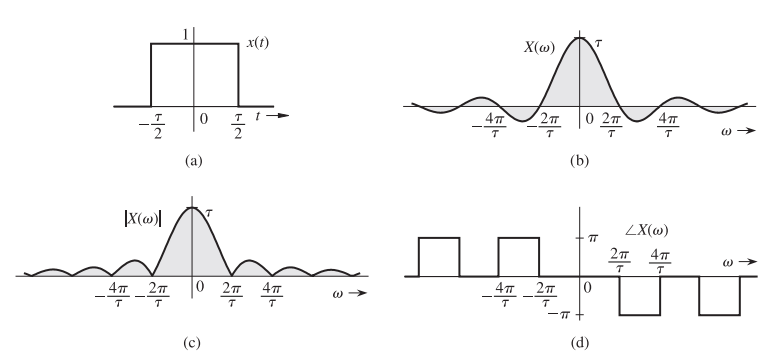

### Questão 9: 

Obtenha a transformada de Fourier par ao impulso unitário $\delta(t).$

#### Solução:

Usando a propriedade de amostragem do impulso, obtemos

$$
\mathcal{F}[\delta(t)]=\int_{-\infty}^{\infty} \delta(t) e^{-j \omega t} d t=1
$$

ou

$$
\delta(t) \Longleftrightarrow 1
$$


In [21]:
w, t = symbols('w t', real = True)
aux9 = simplify(integrate(exp(-1J*w*t)*DiracDelta(t), (t,-oo,oo)))
aux9

1

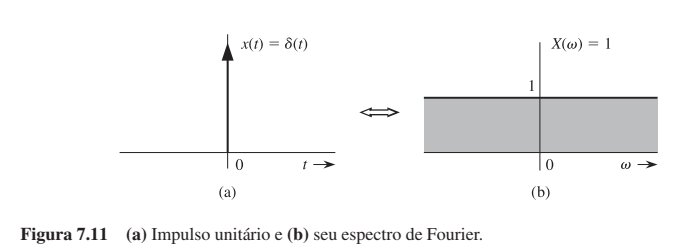

### Questão 10: 

Obtenha a transformada de Fourier inversa de $\delta(\omega)$.

### Solução:


$$
\mathcal{F}^{-1}[\delta(\omega)]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta(\omega) e^{j \omega t} d \omega=\frac{1}{2 \pi}
$$


Portanto,

$$
\frac{1}{2 \pi} \Longleftrightarrow \delta(\omega)
$$

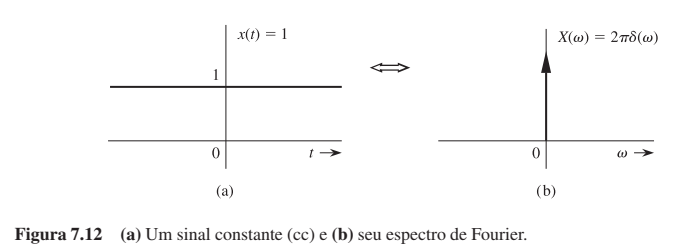


In [22]:
w, t = symbols('w t', real = True)
aux10 = simplify(integrate(exp(1J*w*t)*DiracDelta(w)/(2*pi), (w,-oo,oo)))
aux10

1/(2*pi)

### Questão 11: 

Obtenha a transformada de Fourier inversa de $\delta\left(\omega-\omega_0\right)$.

### Solução:

Usando a propriedade de amostragem da função impulso, obtemos

$$
\mathcal{F}^{-1}\left[\delta\left(\omega-\omega_0\right)\right]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta\left(\omega-\omega_0\right) e^{j \omega t} d \omega=\frac{1}{2 \pi} e^{j \omega_0 t}
$$


Portanto,

$$
\frac{1}{2 \pi} e^{j \omega_0 t} \Longleftrightarrow \delta\left(\omega-\omega_0\right)
$$

ou

$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$


In [23]:
w, w0, t = symbols('w w0 t', real = True)
aux11 = simplify(integrate(exp(1J*w*t)*DiracDelta(w - w0)/(2*pi), (w,-oo,oo)))
aux11

exp(1.0*I*t*w0)/(2*pi)

Assim, temos que 

$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$
e
$$
e^{-j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega+\omega_0\right)
$$

### Questão 12: 

Obtenha a transformada de Fourier da senoide de duração infinita $\cos \omega_0 t$.


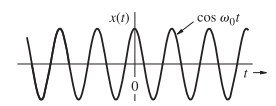

### Solução:

Da fórmula de Euler,

$$
\cos \omega_0 t=\frac{1}{2}\left(e^{j \omega_0 t}+e^{-j \omega_0 t}\right)
$$


Usando o resultado anterior, obtemos

$$
\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega+\omega_0\right)+\delta\left(\omega-\omega_0\right)\right]
$$


In [261]:
t, w, w0 = symbols('t, w, w0', real = True)
simplify(integrate(cos(w0*t)*exp(-1j*w*t),(t,-oo,oo)))

Integral(exp(-1.0*I*t*w)*cos(t*w0), (t, -oo, oo))

### Questão 13: 

Obtenha a transformada de Fourier da função degrau unitário $u(t)$.

### Solução:

Se tentarmos obter a transformada de Fourier de $u(t)$ diretamente pela integração, teremos um resultado indeterminado porque

$$
U(\omega)=\int_{-\infty}^{\infty} u(t) e^{-j \omega t} d t=\int_0^{\infty} e^{-j \omega t} d t=\left.\frac{-1}{j \omega} e^{-j \omega t}\right|_0 ^{\infty}
$$


O limite superior de $e^{-j \omega t}$ quando $t \rightarrow \infty$ resulta em uma resposta indeterminada. Logo, abordamos esse problema considerando $u(t)$ como sendo a exponencial decrescente $e^{-a t} u(t)$ no limite quando $a \rightarrow 0$ (figura abaixo). 

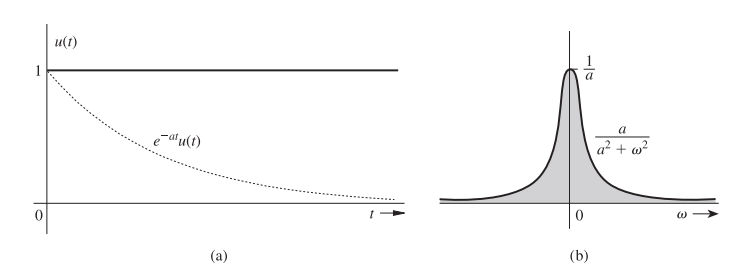

Logo,

$$
u(t)=\lim _{a \rightarrow 0} e^{-a t} u(t)
$$

e

$$
U(\omega)=\lim _{a \rightarrow 0} \mathcal{F}\left\{e^{-a t} u(t)\right\}=\lim _{a \rightarrow 0} \frac{1}{a+j \omega}
$$


Expressar o lado direito em termos de sua parte real e imaginária resulta em

$$
\begin{aligned}
U(\omega) & =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}-j \frac{\omega}{a^2+\omega^2}\right] \\
& =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}\right]+\frac{1}{j \omega}
\end{aligned}
$$


A função $a /\left(a^2+\omega^2\right)$ possui propriedades interessantes. Primeiro, a área sob essa função (Fig. 7.15b) é $\pi$, independente do valor de $a$ :

$$
\int_{-\infty}^{\infty} \frac{a}{a^2+\omega^2} d \omega=\left.\tan ^{-1} \frac{\omega}{a}\right|_{-\infty} ^{\infty}=\pi
$$


Segundo, quando $a \rightarrow 0$, esta função aproxima-se de zero para todo $\omega \neq 0$ e toda a sua área ( $\pi$ ) estará concentrada em um único ponto $\omega=0$. Claramente, quando $a \rightarrow 0$, essa função aproxima-se de um impulso com força $\pi.$ Portanto,

$$
U(\omega)=\pi \delta(\omega)+\frac{1}{j \omega}
$$


### Questão 14: 

Obtenha a transformada de Fourier da função sinal sgn $(t)$, mostrada na figura abaixo.


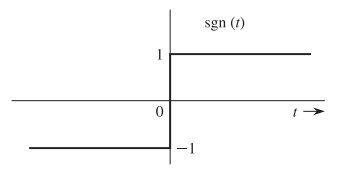

In [9]:
# Definir variáveis
t, omega = sym.symbols('t omega')

# Definir a função sgn(t)
sgn_t = sym.sign(t)

# Definir a Transformada de Fourier
F_omega = sym.integrate(sgn_t * sym.exp(-sym.I * omega * t), (t, -sym.oo, sym.oo))

# Simplificar o resultado
F_omega_simplified = sym.simplify(F_omega)
F_omega_simplified

Piecewise((-2*I/omega, (Abs(arg(omega) - pi/2) < pi/2) & (Abs(arg(omega) + pi/2) < pi/2)), (Integral(Piecewise((0, Eq(t, 0)), (t*exp(-I*omega*t)/Abs(t), True)), (t, -oo, oo)), True))

### Questão 15: 

Mostre que a transformada de Fourier inversa de $X(\omega)$ mostrada na figura abaixo é $x(t)=\left(\omega_0 / \pi\right) \operatorname{sinc}\left(\omega_0 t\right)$. Trace $x(t)$

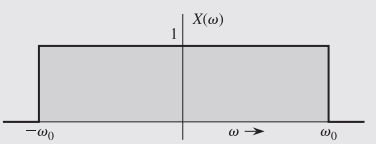

In [ ]:
# Definir as variáveis simbólicas
t, omega, omega_0 = sym.symbols('t omega omega_0', real=True)

# Definir a função retangular X(omega)
X_omega = sym.Piecewise((1, (omega >= -omega_0) & (omega <= omega_0)), (0, True))

# Calcular a transformada de Fourier inversa de X(omega)
inverse_fourier_result = sym.inverse_fourier_transform(X_omega, omega, t)

# Exibir o resultado simplificado
simplified_result = inverse_fourier_result.simplify()
print(simplified_result)

# Garantir que estamos lidando apenas com a parte real
simplified_result_real = sym.re(simplified_result)

# Converter a função sinc para uma expressão numérica
x_t = sym.lambdify(t, simplified_result_real.subs(omega_0, np.pi))

# Gerar valores para t
t_vals = np.linspace(-10, 10, 400)
x_vals = np.real(x_t(t_vals))  # Garantir que os valores sejam reais

# Plotar a função
plt.plot(t_vals, x_vals)
plt.title(r'$x(t) = \frac{\omega_0}{\pi} \cdot \mathrm{sinc}(\omega_0 t)$')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()

### Questão 16: 

Mostre que $\cos \left(\omega_0 t+\theta\right) \Leftrightarrow \pi\left[\delta\left(\omega+\omega_0\right) e^{-j \theta}+\delta\left(\omega-\omega_0\right) e^{j \theta}\right]$.

In [8]:
# Definir as variáveis simbólicas
t, omega, omega0, theta = sym.symbols('t omega omega0 theta', real=True)

# Definir a função cos(ω0 t + θ)
cos_func = sym.cos(omega0 * t + theta)

# Calcular a transformada de Fourier de cos(ω0 t + θ)
fourier_transform_result = sym.fourier_transform(cos_func, t, omega)

# Exibir o resultado
fourier_transform_result.simplify()

FourierTransform(cos(omega0*t + theta), t, omega)

### Questão 17: 

Mostre a ``propriedade da dualidade``, que afirma que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
X(t) \Longleftrightarrow 2 \pi x(-\omega)
$$


#### Solução:

Da equação 
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$

podemos escrever,

$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(u) e^{j u t} d u
$$


Logo,

$$
2 \pi x(-t)=\int_{-\infty}^{\infty} X(u) e^{-j u t} d u
$$


Trocando $t$ por $\omega$ obtemos o resultado.

### Questão 18: 

Sabendo que 

 - $e^{-a t} u(t) \Longleftrightarrow \frac{1}{a+j \omega} \quad a>0$
 
 - $e^{-a|t|} \Longleftrightarrow \frac{2 a}{a^2+\omega^2} \quad a>0$
 
 - $\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega-\omega_0\right)+\delta\left(\omega+\omega_0\right)\right]$
 
 Use o princípio da dualidade para mostrar que 
 
(a) $1 /($ jt $+a) \Longleftrightarrow 2 \pi e^{a \omega} u(-\omega)$

(b) $2 a /\left(t^2+a^2\right) \Longleftrightarrow 2 \pi e^{-a|\omega|}$

(c) $\delta\left(t+t_0\right)+\delta\left(t-t_0\right) \Longleftrightarrow 2 \cos t_0 \omega$

In [7]:

# Definir as variáveis simbólicas
t, omega, a, t0 = sym.symbols('t omega a t0', real=True)

# (a) 1 / (jt + a) ⟺ 2π e^(aω) u(-ω)
# Definir a função 1 / (jt + a)
func_a = 1 / (sym.I * t + a)

# Calcular a transformada de Fourier inversa
fourier_inv_a = sym.inverse_fourier_transform(func_a, omega, t)

# (b) 2a / (t^2 + a^2) ⟺ 2π e^(-a|ω|)
# Definir a função 2a / (t^2 + a^2)
func_b = 2 * a / (t**2 + a**2)

# Calcular a transformada de Fourier inversa
fourier_inv_b = sym.inverse_fourier_transform(func_b, omega, t)

# (c) δ(t + t0) + δ(t - t0) ⟺ 2 cos(t0 ω)
# Definir a função δ(t + t0) + δ(t - t0)
func_c = sym.DiracDelta(t + t0) + sym.DiracDelta(t - t0)

# Calcular a transformada de Fourier inversa
fourier_inv_c = sym.fourier_transform(func_c, t, omega)

# Exibir os resultados
fourier_inv_a, fourier_inv_b, fourier_inv_c.simplify()

(0, 0, 2*cos(2*pi*omega*t0))

### Questão 19: 

Demonstre a ``propriedade do escalamento``, que diz que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então, para qualquer constante real $a$,

$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$


#### Prova. 
Para uma constante real positiva $a$,

$$
\begin{aligned}
\mathcal{F}[x(a t)] & =\int_{-\infty}^{\infty} x(a t) e^{-j \omega t} d t \\
& =\frac{1}{a} \int_{-\infty}^{\infty} x(u) e^{(-j \omega / a) u} d u=\frac{1}{a} X\left(\frac{\omega}{a}\right)
\end{aligned}
$$


Similarmente, podemos demonstrar que se $a<0$,

$$
x(a t) \Longleftrightarrow \frac{-1}{a} X\left(\frac{\omega}{a}\right)
$$


### Questão 20: 

Demonstre a ``Propriedade de Deslocamento no Tempo`` que assegura que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}
$$


Utilize esse resultado para obter a transformada de Fourier de $e^{-a\left|t-t_o\right|}$.

#### Prova.

Pela definição,

$$
\mathcal{F}\left[x\left(t-t_0\right)\right]=\int_{-\infty}^\omega x\left(t-t_0\right) e^{-j \omega t} d t
$$


Fazendo $t-t_0=u$, temos

$$
\begin{aligned}
\mathcal{F}\left[x\left(t-t_0\right)\right] & =\int_{-\infty}^{\infty} x(u) e^{-j \omega\left(u+t_0\right)} d u \\
& =e^{-j \omega t_0} \int_{-\infty}^{\infty} x(u) e^{-j \omega u} d u=X(\omega) e^{-j \omega t_0}
\end{aligned}
$$


``Esse resultado mostra que atrasar um sinal por $t_0$ segundos não altera seu espectro de amplitude. $O$ espectro de fase, entretanto, é alterado por $-\omega t_0$.``

### Questão 21:  Demonstre as seguintes propriedades

 
 - i) Deslocamento na frequência $\left(\omega_0\right.$ real ) $x(t) e^{j \omega_0 t}  \Longleftrightarrow X\left(\omega-\omega_0\right)$
 
 - ii) Convolução no tempo $x_1(t) * x_2(t)  \Longleftrightarrow X_1(\omega) X_2(\omega)$  
 
 - iii) Convolução na frequência $x_1(t) x_2(t) \Longleftrightarrow \frac{1}{2 \pi} X_1(\omega) * X_2(\omega)$  
 
 - iv) Diferenciação no tempo $\frac{d^n x}{d t^n} \Longleftrightarrow (j \omega)^n X(\omega)$
 
 - v) Integração no tempo $\int_{-\infty}^t x(u) d u \Longleftrightarrow \frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)$


#### Prova i). 

Pela definição

$$
\mathcal{F}\left[x(t) e^{j \omega_0 t}\right]=\int_{-\infty}^{\infty} x(t) e^{j \omega_0 t} e^{-j \omega t} d t=\int_{-\infty}^{\infty} x(t) e^{-j\left(\omega-\omega_0\right) t} d t=X\left(\omega-\omega_0\right)
$$


De acordo com essa propriedade, a multiplicação de um sinal por um fator $e^{j \omega_0 t}$ desloca o espectro do sinal por $\omega=\omega_0$. Note a dualidade entre as propriedades de deslocamento no tempo e deslocamento na frequência.

Trocando $\omega_0$ por $-\omega_0$ resulta em

$$
x(t) e^{-j \omega_0 t} \Longleftrightarrow X\left(\omega+\omega_0\right)
$$


Como $e^{j \omega_0 t}$ não é uma função real que pode ser gerada, o deslocamento na frequência na prática é obtido multiplicando $x(t)$ por uma senóide. Observe que

$$
x(t) \cos \omega_0 t=\frac{1}{2}\left[x(t) e^{j \omega_0 t}+x(t) e^{-j \omega_0 t}\right]
$$


Assim, temos

$$
x(t) \cos \omega_0 t \Longleftrightarrow \frac{1}{2}\left[X\left(\omega-\omega_0\right)+X\left(\omega+\omega_0\right)\right]
$$


#### Prova ii).

Pela definição

$$
\begin{aligned}
\mathcal{F}\left|x_1(t) * x_2(t)\right| & =\int_{-\infty}^{\infty} e^{-j \omega t}\left[\int_{-\infty}^{\infty} x_1(\tau) x_2(t-\tau) d \tau\right] d t \\
& =\int_{-\infty}^{\infty} x_1(\tau)\left[\int_{-\infty}^{\infty} e^{-j \omega t} x_2(t-\tau) d t\right] d \tau
\end{aligned}
$$


A integral interna é a transformada de Fourier de $x_2(t-\tau)$, dada por [propriedade de deslocamento no tempo da Eq. (7.37)] $X_2(\omega) e^{-j \omega t}$. Logo,

$$
\mathcal{F}\left[x_1(t) * x_2(t)\right]=\int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} X_2(\omega) d \tau=X_2(\omega) \int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} d \tau=X_1(\omega) X_2(\omega)
$$

seja $H(\omega)$ a transformada de Fourier da resposta ao impulso unitário $h(t)$, ou seja,

$$
h(t) \Longleftrightarrow H(\omega)
$$


A aplicação da propriedade de convolução no tempo a $y(t)=x(t) * h(t)$ resulta em (assumindo que tanto $x(t)$ quanto $h(t)$ possuem suas transformadas de Fourier)

$$
Y(\omega)=X(\omega) H(\omega)
$$


In [6]:
t, tau = sym.symbols('t tau', real=True)
# iii) Convolução no tempo
# Convolução no tempo de duas funções x1(t) e x2(t)
x1_t = sym.Function('x1')(t)
x2_t = sym.Function('x2')(t)
convolucao_tempo = sym.integrate(x1_t * x2_t.subs(t, t - tau), (tau, -sym.oo, sym.oo))

#### Prova iv).

A diferenciação dos dois lados da equação $x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$ resulta em

$$
\frac{d x}{d t}=\frac{1}{2 \pi} \int_{-\infty}^{\infty} j \omega X(\omega) e^{j \omega t} d \omega
$$


Esse resultado mostra que


$$
\frac{d x}{d t} \Longleftrightarrow j \omega X(\omega)
$$


A aplicação repetida dessa propriedade leva a

$$
\frac{d^n x}{d t^n} \Longleftrightarrow(j \omega)^n X(\omega)
$$


#### Prova v)

temos que

$$
x(t) * u(t)=\int_{-\infty}^{\infty} x(\tau) u(t-\tau) d \tau=\int_{-\infty}^t x(\tau) d \tau
$$


Agora, da propriedade de convolução no tempo, temos que

$$
\begin{aligned}
x(t) * u(t) & =\int_{-\infty}^t x(\tau) d \tau \Longleftrightarrow X(\omega)\left[\frac{1}{j \omega}+\pi \delta(\omega)\right] \\
& =\frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)
\end{aligned}
$$


### Questão 22:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier do pulso triangular $\Delta(t / \tau)$ apresentado abaixo.

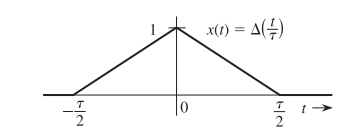

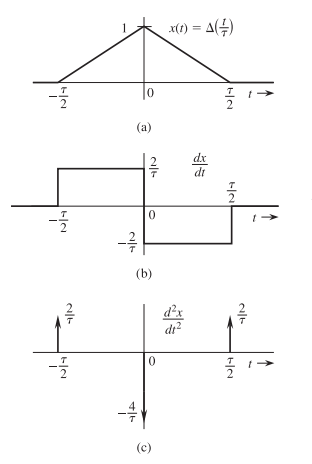

$$
\frac{d^2 x}{d t^2}=\frac{2}{\tau}\left[\delta\left(t+\frac{\tau}{2}\right)-2 \delta(t)+\delta\left(t-\frac{\tau}{2}\right)\right]
$$

Usando a propriedade de diferenciação no tempo:
$$
\frac{d^2 x}{d t^2} \Longleftrightarrow(j \omega)^2 X(\omega)=-\omega^2 X(\omega)
$$

Além disso, da propriedade de deslocamento no tempo:

$$
\delta\left(t-t_0\right) \Longleftrightarrow e^{-j \omega t_0}
$$


Obtemos

$$
-\omega^2 X(\omega)=\frac{2}{\tau}\left[e^{j(\omega \tau / 2)}-2+e^{-j(\omega \tau / 2)}\right]=\frac{4}{\tau}\left(\cos \frac{\omega \tau}{2}-1\right)=-\frac{8}{\tau} \operatorname{sen}^2\left(\frac{\omega \tau}{4}\right)
$$

e

$$
X(\omega)=\frac{8}{\omega^2 \tau} \operatorname{sen}^2\left(\frac{\omega \tau}{4}\right)=\frac{\tau}{2}\left[\frac{\operatorname{sen}\left(\frac{\omega \tau}{4}\right)}{\frac{\omega \tau}{4}}\right]^2=\frac{\tau}{2} \operatorname{sinc}^2\left(\frac{\omega \tau}{4}\right)
$$


### Questão 23:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier de ret $(t / \tau)$.

**Solução:** temos

1. **Função Retangular:**
   a função $\text{ret}(t/\tau)$ pode ser definida como:
   $$
   \text{ret}\left(\frac{t}{\tau}\right) =
   \begin{cases} 
   1, & \text{se } |t| < \frac{\tau}{2} \\
   0, & \text{se } |t| > \frac{\tau}{2}
   \end{cases}
   $$
  
2. **Transformada de Fourier da Função Retangular:**
   a transformada de Fourier de uma função retangular $\text{rect}(t/\tau)$ é dada por:
   $$
   \mathcal{F}\left\{\text{ret}\left(\frac{t}{\tau}\right)\right\} = \tau \, \text{sinc}\left(\frac{\omega \tau}{2}\right)
   $$
   

3. **Diferenciação no Tempo:**
   a propriedade de diferenciação no tempo da transformada de Fourier afirma que
   $$
   \frac{d^n x}{d t^n} \Longleftrightarrow (j \omega)^n X(\omega)
   $$
   
4. **Aplicando a Propriedade:**
temos que,
$$
\frac{d x}{d t} = \delta \left( t + \frac{\tau}{2} \right)  - \delta \left( t - \frac{\tau}{2} \right) 
$$
Por outro lado, 
$$
\frac{d x}{d t} \iff (j\omega) X(\omega) 
$$



Da propriedade de deslocamento no tempo:

$$
\delta\left(t-t_0\right) \Longleftrightarrow e^{-j \omega t_0}
$$
Assim,

$$
(j \omega) X(\omega) \Longleftrightarrow \frac{d x}{d t} = \delta \left( t + \frac{\tau}{2} \right)  - \delta \left( t - \frac{\tau}{2} \right)  \Longleftrightarrow e^{j \omega \frac{\tau}{2}} - e^{-j \omega \frac{\tau}{2}} = 2jsin(\omega \frac{\tau}{2})
$$
Donde, 
$$
X(\omega) \Longleftrightarrow  \frac{2sin( \frac{\omega\tau}{2})}{\omega} = \frac{ \tau sin(\frac{\omega \tau}{2})}{\frac{\omega\tau }{2}} = \tau \, \text{sinc}\left(\frac{\omega \tau}{2}\right)
$$